In [1]:
# Install Dependencies

#!pip install imbalanced-learn
#!pip install --upgrade xgboost
#!pip install --upgrade scikit-learn xgboost imbalanced-learn

In [2]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold
from sklearn.metrics import precision_recall_curve, average_precision_score

from xgboost import XGBClassifier


# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/creditcardfraud/creditcard.csv


Data Science Exercise: Real-Time Credit Card Fraud Detection
Phase 1: Data Strategy & Exploratory Data Analysis (EDA)
The core challenge in fraud detection is the extreme class imbalance (typically < 0.2% of transactions are fraudulent).



## 1. Data Acquisition and Cleaning
Source Data: A synthetic or anonymized dataset containing transaction information.

Key Features:

Time: Seconds elapsed between the transaction and the first transaction in the dataset.

Amount: Transaction amount.

V1-V28: Principal Component Analysis (PCA) transformed features (often provided to anonymize sensitive information).

Class: The target variable (0 for Non-Fraud, 1 for Fraud).

Data Cleaning:

Check for and handle missing values (though PCA-transformed data often has none).

Ensure data types are correct (e.g., Time and Amount as numerical).


In [3]:
df = pd.read_csv('/kaggle/input/creditcardfraud/creditcard.csv')

Note: Time is the Number of seconds elapsed between this transaction and the first transaction in the dataset

With 172792, about two days worth of data is collected.

In [4]:
df['Time'].describe()

count    284807.000000
mean      94813.859575
std       47488.145955
min           0.000000
25%       54201.500000
50%       84692.000000
75%      139320.500000
max      172792.000000
Name: Time, dtype: float64

In [5]:
df.head(15)

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0
5,2.0,-0.425966,0.960523,1.141109,-0.168252,0.420987,-0.029728,0.476201,0.260314,-0.568671,...,-0.208254,-0.559825,-0.026398,-0.371427,-0.232794,0.105915,0.253844,0.081080,3.67,0
6,4.0,1.229658,0.141004,0.045371,1.202613,0.191881,0.272708,-0.005159,0.081213,0.464960,...,-0.167716,-0.270710,-0.154104,-0.780055,0.750137,-0.257237,0.034507,0.005168,4.99,0
7,7.0,-0.644269,1.417964,1.074380,-0.492199,0.948934,0.428118,1.120631,-3.807864,0.615375,...,1.943465,-1.015455,0.057504,-0.649709,-0.415267,-0.051634,-1.206921,-1.085339,40.80,0
8,7.0,-0.894286,0.286157,-0.113192,-0.271526,2.669599,3.721818,0.370145,0.851084,-0.392048,...,-0.073425,-0.268092,-0.204233,1.011592,0.373205,-0.384157,0.011747,0.142404,93.20,0
9,9.0,-0.338262,1.119593,1.044367,-0.222187,0.499361,-0.246761,0.651583,0.069539,-0.736727,...,-0.246914,-0.633753,-0.120794,-0.385050,-0.069733,0.094199,0.246219,0.083076,3.68,0


In [6]:
# check all values are numerical
df.dtypes

Time      float64
V1        float64
V2        float64
V3        float64
V4        float64
V5        float64
V6        float64
V7        float64
V8        float64
V9        float64
V10       float64
V11       float64
V12       float64
V13       float64
V14       float64
V15       float64
V16       float64
V17       float64
V18       float64
V19       float64
V20       float64
V21       float64
V22       float64
V23       float64
V24       float64
V25       float64
V26       float64
V27       float64
V28       float64
Amount    float64
Class       int64
dtype: object

In [7]:
# Count missing values in each column
missing_counts = df.isna().sum()
print(missing_counts)

Time      0
V1        0
V2        0
V3        0
V4        0
V5        0
V6        0
V7        0
V8        0
V9        0
V10       0
V11       0
V12       0
V13       0
V14       0
V15       0
V16       0
V17       0
V18       0
V19       0
V20       0
V21       0
V22       0
V23       0
V24       0
V25       0
V26       0
V27       0
V28       0
Amount    0
Class     0
dtype: int64


## 2. Exploratory Data Analysis (EDA)


Target Variable Distribution: Quantify the imbalance. Calculate the percentage of fraud cases.

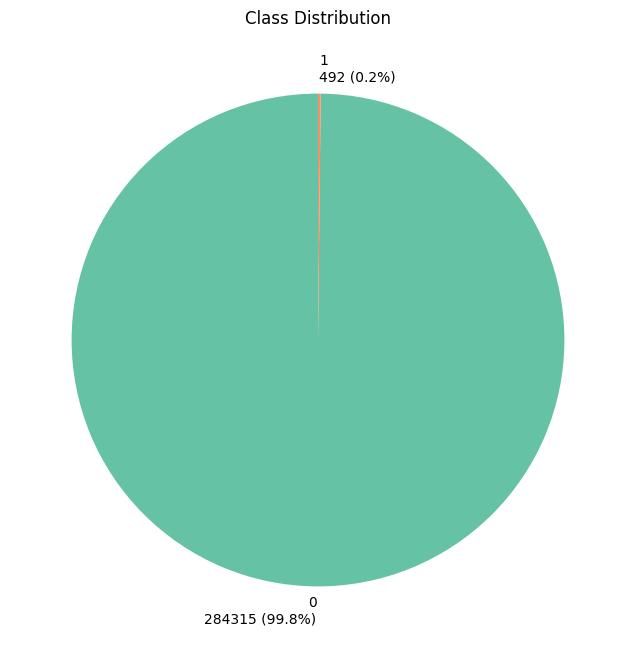

In [8]:
# Example data
counts = df['Class'].value_counts()

labels = counts.index
sizes = counts.values

# Calculate percentages
percentages = [f'{(size / sizes.sum()) * 100:.1f}%' for size in sizes]

# Combine labels with absolute and percentage values
combined_labels = [f'{label}\n{size} ({perc})' for label, size, perc in zip(labels, sizes, percentages)]

# Plot pie chart
plt.figure(figsize=(8, 8))
plt.pie(sizes, labels=combined_labels, autopct=None, startangle=90, colors=plt.cm.Set2.colors)
plt.title('Class Distribution')
plt.show()


<module 'matplotlib.pyplot' from '/usr/local/lib/python3.11/dist-packages/matplotlib/pyplot.py'>

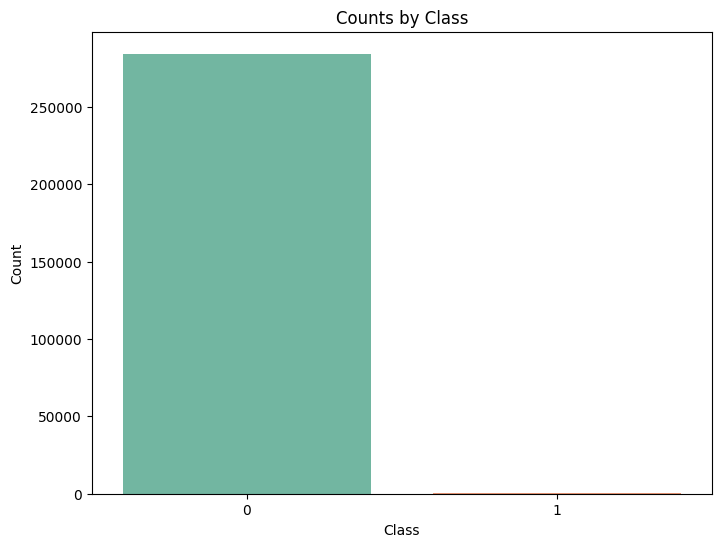

In [9]:
# Assume your DataFrame is df and the column is 'class'
plt.figure(figsize=(8, 6))
sns.countplot(x='Class', data=df, palette='Set2')

plt.title('Counts by Class')
plt.xlabel('Class')
plt.ylabel('Count')
plt


Feature-Target Relationship:


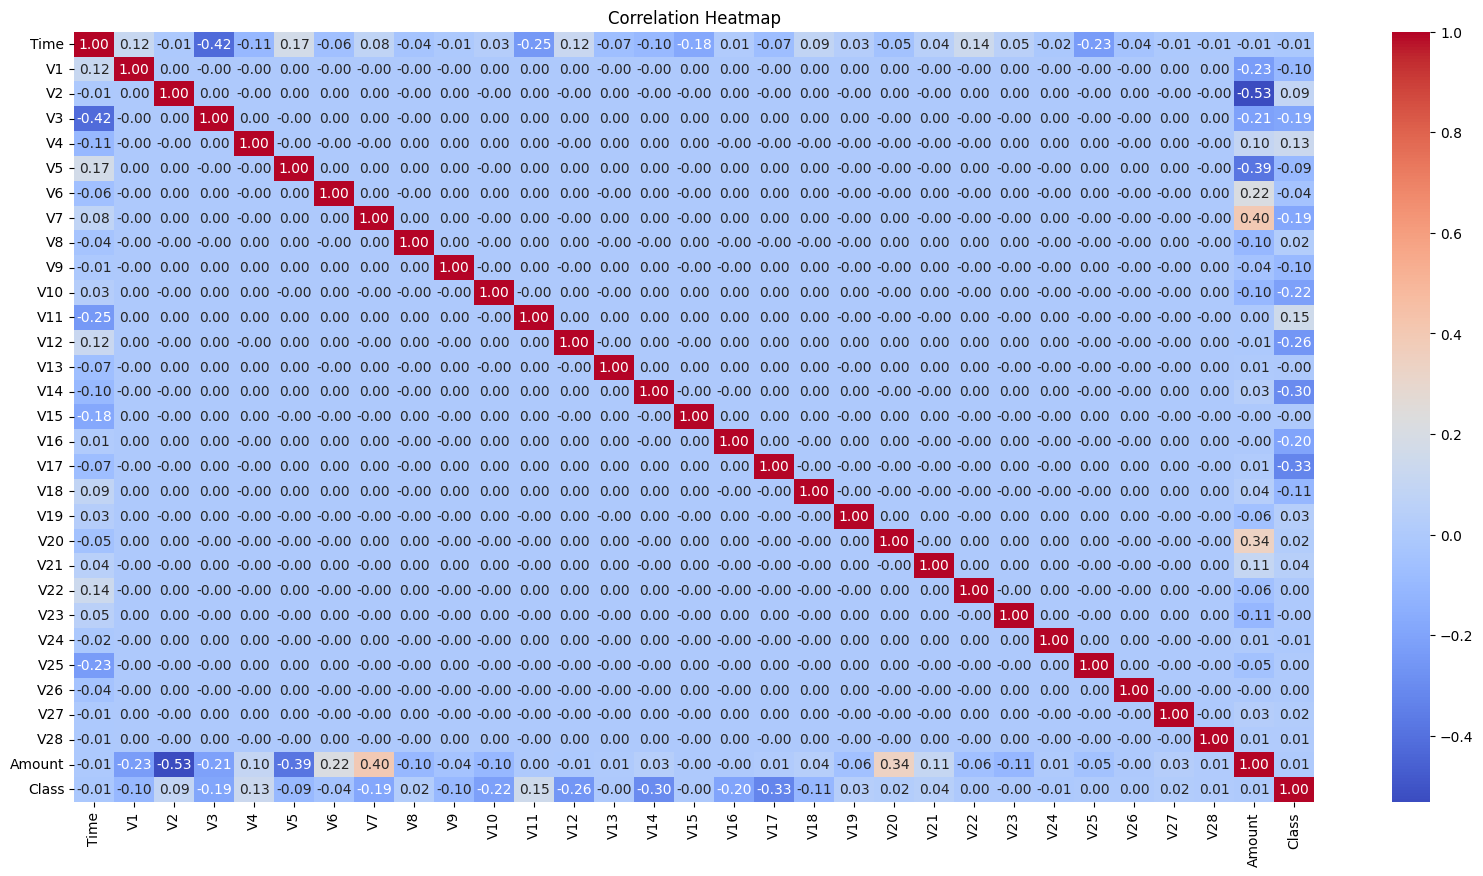

In [10]:
# Corr Plot

corr = df.corr()


plt.figure(figsize=(20, 10))  # Adjust size for 28 features
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", cbar=True)
plt.title("Correlation Heatmap")
plt.show()


Plot the distribution of Amount for fraudulent vs. non-fraudulent transactions (e.g., using a box plot). You'll likely see that fraudulent transactions, while rare, sometimes have a different distribution of amounts.

Based on the corr plot, V12, V14, and V17 are weakly correlated to the target Class. 

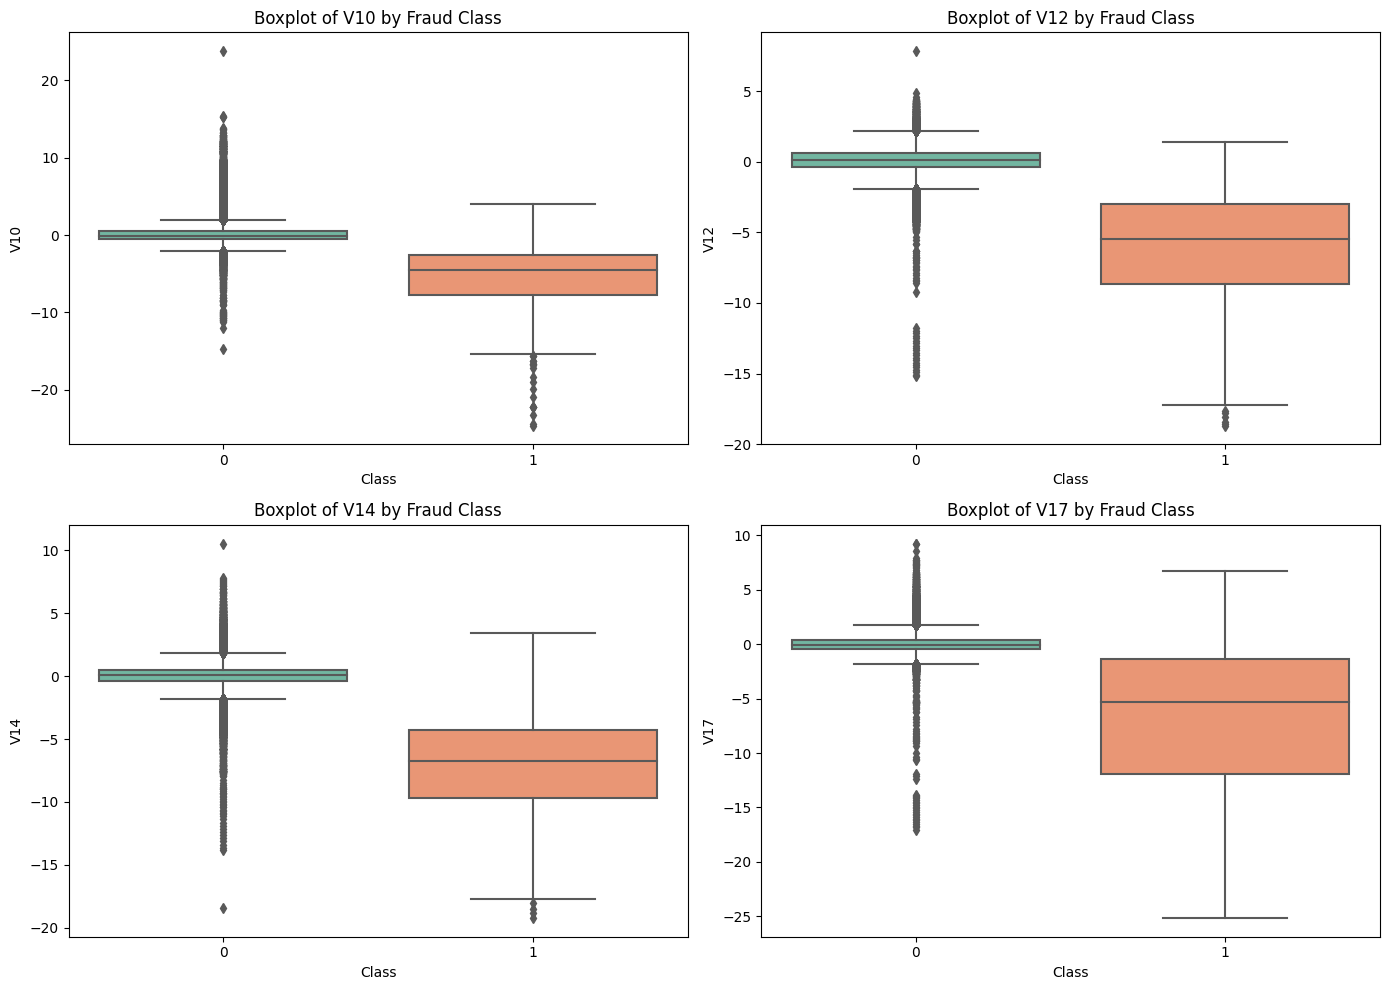

In [11]:
num_vars = ['V10','V12', 'V14', 'V17']

# Set up the figure with 2 rows and 2 columns (for 4 plots)
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Flatten axes for easy iteration
axes = axes.flatten()

for i, var in enumerate(num_vars):
    sns.boxplot(x='Class', y=var, data=df, ax=axes[i], palette="Set2")
    axes[i].set_title(f'Boxplot of {var} by Fraud Class')

plt.tight_layout()
plt.show()


For sanity, create a box plot where there is not a correlation between target class. I would expect similar distribution and median. Class 1 has more spread because less observations. 

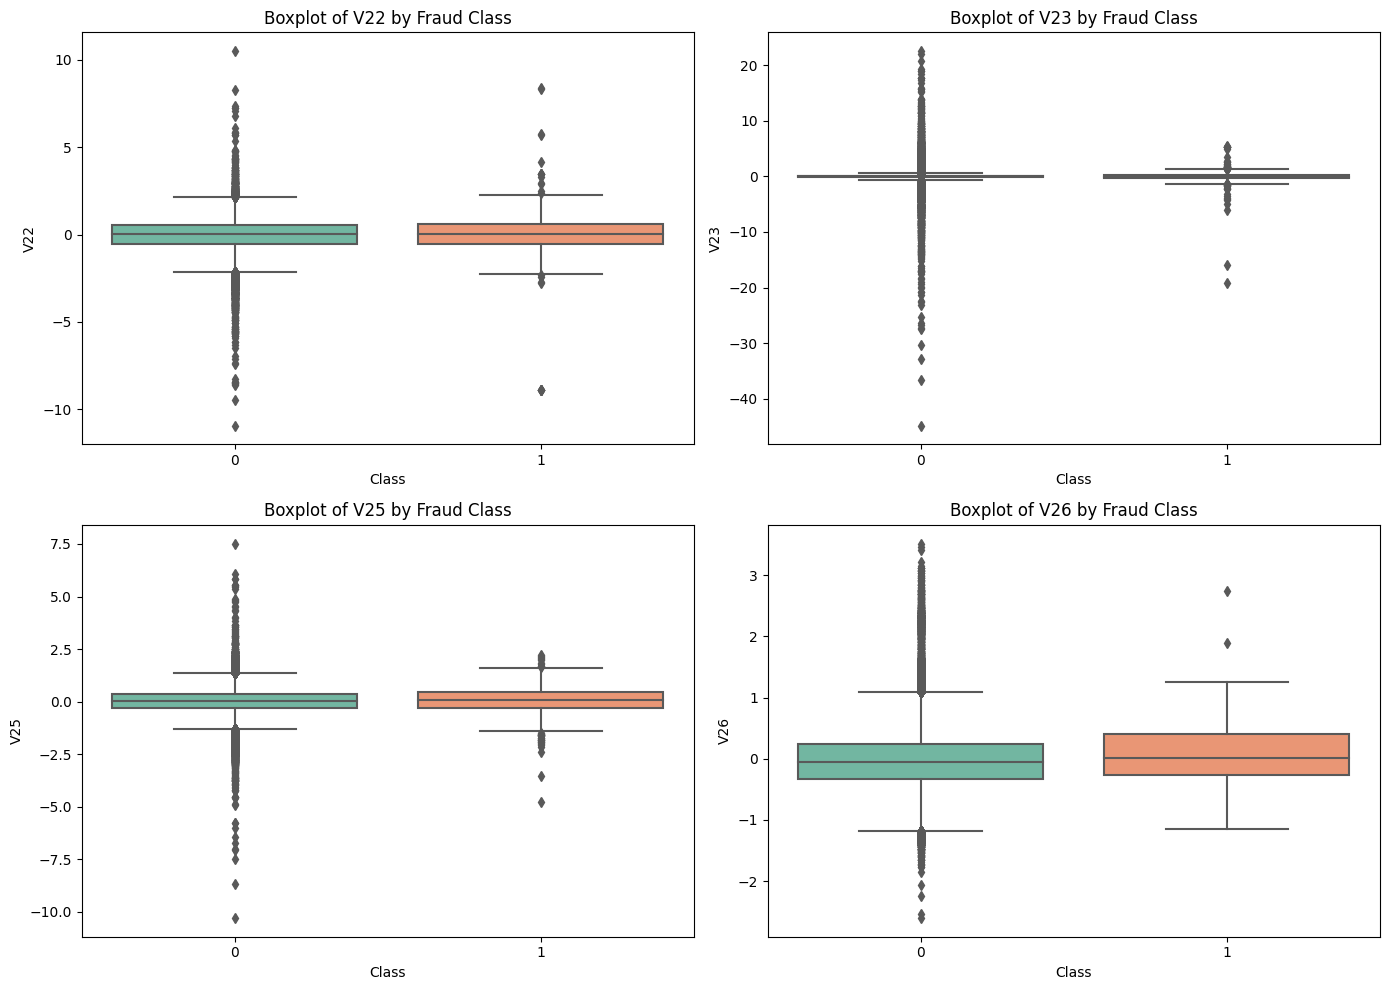

In [12]:
num_vars = ['V22','V23', 'V25', 'V26']

# Set up the figure with 2 rows and 2 columns (for 4 plots)
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Flatten axes for easy iteration
axes = axes.flatten()

for i, var in enumerate(num_vars):
    sns.boxplot(x='Class', y=var, data=df, ax=axes[i], palette="Set2")
    axes[i].set_title(f'Boxplot of {var} by Fraud Class')

plt.tight_layout()
plt.show()

Analyze the Time feature. Fraud often occurs in concentrated bursts (e.g., right after a data breach) or exhibits daily/weekly cyclical patterns (e.g., more fraud overnight).

/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


Text(0, 0.5, 'Fraud Count')

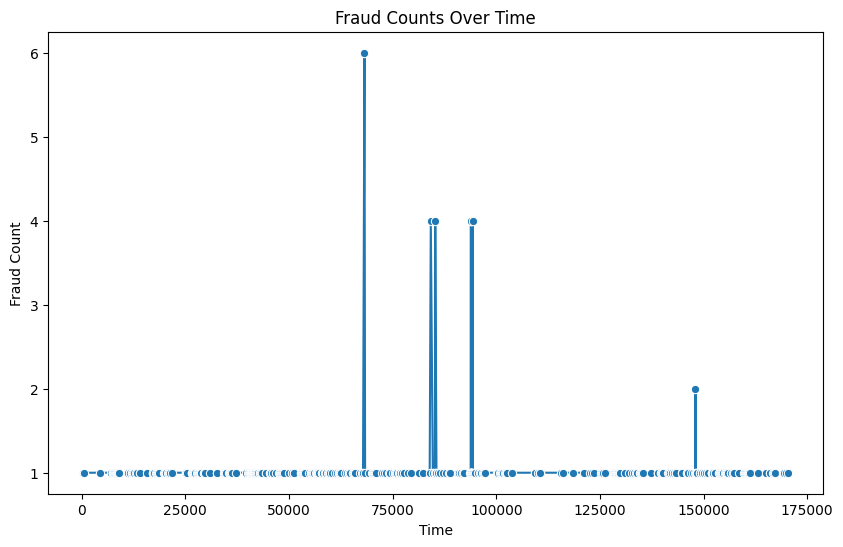

In [13]:
fraud_counts = df[df['Class'] == 1].groupby('Time').size().reset_index(name='fraud_count')


plt.figure(figsize=(10, 6))
sns.lineplot(x='Time', y='fraud_count', data=fraud_counts, marker='o')
plt.title('Fraud Counts Over Time')
plt.xlabel('Time')
plt.ylabel('Fraud Count')



In [14]:
fraud_counts_sorted = fraud_counts.sort_values(by='fraud_count', ascending=False)
fraud_counts_sorted.describe()

,Time,fraud_count
count,468.000000,468.000000
mean,80346.179487,1.051282
std,48883.099126,0.410695
min,406.000000,1.000000
25%,41190.750000,1.000000
50%,71680.000000,1.000000
75%,129195.000000,1.000000
max,170348.000000,6.000000


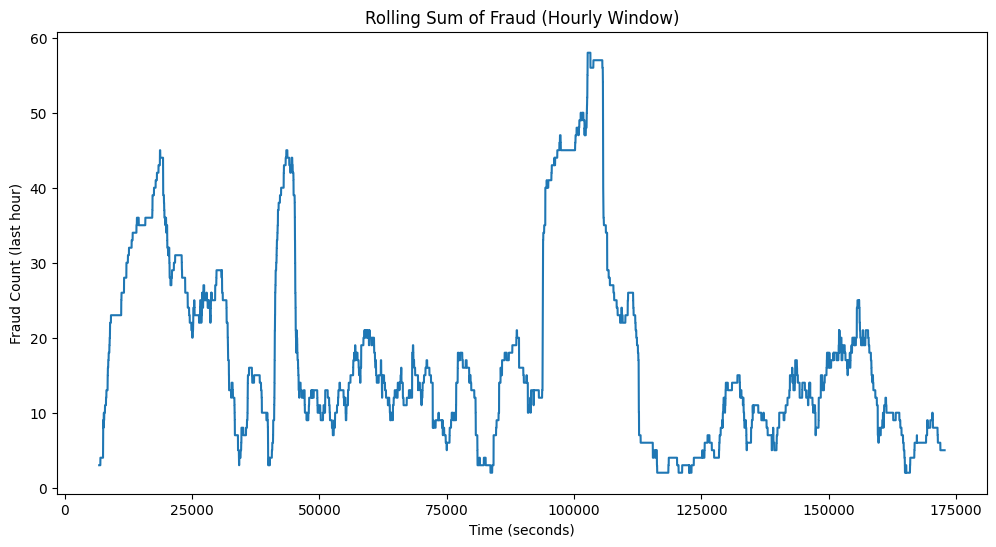

In [15]:

df_grouped = df.groupby('Time', as_index=False)['Class'].sum()


df_grouped.set_index('Time', inplace=True)

# Rolling sum of fraud indicator (class == 1)
df_grouped['fraud_rolling_sum'] = df_grouped['Class'].rolling(window=3600).sum()


df_grouped['fraud_rolling_sum'].plot(figsize=(12, 6))
plt.title('Rolling Sum of Fraud (Hourly Window)')
plt.xlabel('Time (seconds)')
plt.ylabel('Fraud Count (last hour)')
plt.show()



## Phase 2: Model Development



1. Feature Engineering
Because transaction data often has limited raw features, engineering velocity features is critical.

Transaction Velocity: Calculate aggregated statistics within rolling time windows:


Cyclical Time Features: Convert the raw Time feature (seconds/timestamp) into features that capture periodicity (e.g., time of day, day of week) using sine and cosine transformations.


In [16]:
selected_cols = ['V10','V12', 'V14', 'V17']
# 1. Statistical Features across PCA components
pca_cols = [col for col in selected_cols]
df['pca_mean'] = df[pca_cols].mean(axis=1)
df['pca_std'] = df[pca_cols].std(axis=1)
df['pca_abs_sum'] = df[pca_cols].abs().sum(axis=1)
df['pca_max'] = df[pca_cols].max(axis=1)
df['pca_min'] = df[pca_cols].min(axis=1)
df['pca_range'] = df['pca_max'] - df['pca_min']



## 2. Handling Class Imbalance (The Crucial Step)
Ignoring the imbalance will lead to a model that predicts "Non-Fraud" for almost everything, achieving high accuracy but being useless.

Sampling Techniques:

Under-sampling: Randomly remove majority class (Non-Fraud) examples. Trade-off: Loss of potentially valuable information.

Over-sampling: Use techniques like SMOTE (Synthetic Minority Over-sampling Technique) to generate synthetic fraud examples. Trade-off: Can lead to overfitting.



In [17]:

from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler
from imblearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Assume df is your DataFrame
X = df.drop('Class', axis=1)
y = df['Class']

# 1. Train-Test Split (Stratified)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, stratify=y, random_state=42)

# 2. Scale Features (important for SMOTE)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 3. Define Resampling Strategy
smote = SMOTE(sampling_strategy=0.1, random_state=42)  # Oversample minority to 10% of majority
under = RandomUnderSampler(sampling_strategy=0.5, random_state=42)  # Undersample majority to 50%

# Combine SMOTE + Undersampling in a pipeline
resample_pipeline = Pipeline(steps=[('smote', smote), ('under', under)])

# 4. Apply Resampling
X_resampled, y_resampled = resample_pipeline.fit_resample(X_train_scaled, y_train)

print("Original class distribution:", y_train.value_counts())
print("Resampled class distribution:", y_resampled.value_counts())

Original class distribution: Class
0    199020
1       344
Name: count, dtype: int64
Resampled class distribution: Class
0    39804
1    19902
Name: count, dtype: int64



## 3. Algorithm Selection & Training
Baseline Model: Logistic Regression (Simple, fast, highly interpretable).

Production Model: Gradient Boosting Machines (GBMs) like XGBoost or LightGBM.

Why: They handle complex, non-linear relationships well, are robust to outliers, and often yield the best performance in classification tasks.

Trade-off: They are less interpretable than Logistic Regression.

Recommended: Use scale_pos_weight within an algorithm like XGBoost/LightGBM, which internally balances the loss function without physically changing the dataset size.


In [18]:

from xgboost import XGBClassifier
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix

# Initialize XGBoost model with default parameters
model = XGBClassifier()

# Train on resampled data
model.fit(X_resampled, y_resampled)

# Predict on original test set
y_pred = model.predict(X_test_scaled)
y_pred_proba = model.predict_proba(X_test_scaled)[:, 1]





## 4. Evaluation and Hyperparameter Tuning

**The choice of metric is paramount. Accuracy is useless here.**

### Primary Metrics
- **Precision (Specificity)**  
  Of all transactions predicted as fraud, how many were actually fraud?  
  → Minimizes false alarms for customers/banks.

- **Recall (Sensitivity)**  
  Of all actual fraudulent transactions, how many did we catch?  
  → Minimizes actual fraud that gets through.

- **F1-Score**  
  The harmonic mean of Precision and Recall.

- **Area Under the Precision-Recall Curve (AUC-PR)**  
  Best single metric for severely imbalanced datasets, as it directly focuses on positive class performance.

---

### Cross-Validation
Use **Stratified K-Fold** to ensure each fold maintains the same rare proportion of the fraud class.

---

## ✅ Key Metrics to Track

### Recall (Sensitivity or True Positive Rate)
Measures how many actual fraud cases you correctly identify.  
**Formula:**  
$$
\text{Recall} = \frac{\text{True Positives}}{\text{True Positives + False Negatives}}
$$  
High recall is critical because missing fraud is costly.

---

### Precision
Measures how many predicted fraud cases are actually fraud.  
**Formula:**  
$$
\text{Precision} = \frac{\text{True Positives}}{\text{True Positives + False Positives}}
$$  
Important to avoid too many false alarms.

---

### F1-Score
Harmonic mean of Precision and Recall.  
Good for balancing both metrics.

---

### ROC-AUC
Area under the Receiver Operating Characteristic curve.  
Shows overall ability to separate fraud vs. non-fraud across thresholds.

---

### PR-AUC (Precision-Recall AUC)
Even better for imbalanced data because it focuses on minority class performance.

4. Evaluation and Hyperparameter Tuning

The choice of metric is paramount. Accuracy is useless here.

Primary Metrics


Precision (Specificity)
Of all transactions predicted as fraud, how many were actually fraud?
→ Minimizes false alarms for customers/banks.


Recall (Sensitivity)
Of all actual fraudulent transactions, how many did we catch?
→ Minimizes actual fraud that gets through.


F1-Score
The harmonic mean of Precision and Recall.


Area Under the Precision-Recall Curve (AUC-PR)
Best single metric for severely imbalanced datasets, as it directly focuses on positive class performance.



Cross-Validation
Use Stratified K-Fold to ensure each fold maintains the same rare proportion of the fraud class.

✅ Key Metrics to Track
Recall (Sensitivity or True Positive Rate)
Measures how many actual fraud cases you correctly identify.
Formula:
Recall=True PositivesTrue Positives + False Negatives\text{Recall} = \frac{\text{True Positives}}{\text{True Positives + False Negatives}}Recall=True Positives + False NegativesTrue Positives​
Why it matters: High recall is critical because missing fraud is costly.

Precision
Measures how many predicted fraud cases are actually fraud.
Formula:
Precision=True PositivesTrue Positives + False Positives\text{Precision} = \frac{\text{True Positives}}{\text{True Positives + False Positives}}Precision=True Positives + False PositivesTrue Positives​
Why it matters: Important to avoid too many false alarms.

F1-Score
Harmonic mean of Precision and Recall.
Why it matters: Good for balancing both metrics.

ROC-AUC
Area under the Receiver Operating Characteristic curve.
Why it matters: Shows overall ability to separate fraud vs. non-fraud across thresholds.

PR-AUC (Precision-Recall AUC)


In [19]:
# Evaluate
print("ROC-AUC:", roc_auc_score(y_test, y_pred_proba))
print(classification_report(y_test, y_pred))

ROC-AUC: 0.9801160281566519
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     85295
           1       0.61      0.83      0.70       148

    accuracy                           1.00     85443
   macro avg       0.80      0.92      0.85     85443
weighted avg       1.00      1.00      1.00     85443



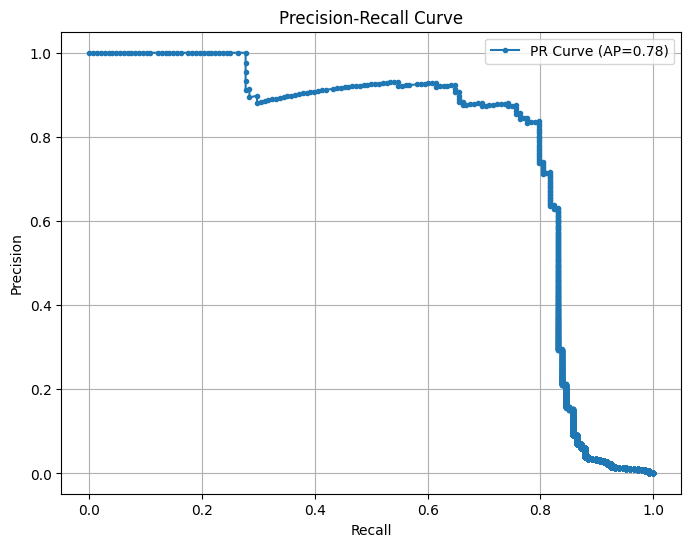

<Figure size 800x600 with 0 Axes>

<Figure size 800x600 with 0 Axes>

In [20]:

from sklearn.metrics import precision_recall_curve, average_precision_score

# Assume you have:
# y_test = true labels
# y_pred_proba = predicted probabilities for Class = 1 (fraud)

# Compute precision, recall, thresholds
precision, recall, thresholds = precision_recall_curve(y_test, y_pred_proba)

# Compute average precision# Compute average precision (PR-AUC)
avg_precision = average_precision_score(y_test, y_pred_proba)

# Plot Precision-Recall curve
plt.figure(figsize=(8, 6))
plt.plot(recall, precision, marker='.', label=f'PR Curve (AP={avg_precision:.2f})')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.legend()
plt.grid()
plt.show()

# Optional: Plot Precision and Recall vs Threshold
plt.figure(figsize=(8, 6))


```python
# Define parameter distributions
param_dist = {
    'n_estimators': [100, 200, 500, 800],
    'max_depth': [3, 4, 5, 6, 8],
    'learning_rate': [0.01, 0.05, 0.1, 0.2],
    'subsample': [0.6, 0.8, 1.0],
    'colsample_bytree': [0.6, 0.8, 1.0],
    'gamma': [0, 1, 5],
    'min_child_weight': [1, 3, 5, 7],
    'scale_pos_weight': [50, 100, 200]  # based on imbalance ratio
}

# Initialize model
xgb = XGBClassifier(random_state=42, use_label_encoder=False, eval_metric='logloss')

# Stratified CV for imbalance
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Randomized Search
random_search = RandomizedSearchCV(
    estimator=xgb,
    param_distributions=param_dist,
    n_iter=50,  # number of random combinations
    scoring='average_precision',  # PR-AUC for imbalance
    cv=cv,
    verbose=2,
    random_state=42,
    n_jobs=-1
)

# Fit on resampled training data
random_search.fit(X_resampled, y_resampled)

In [21]:
# Define parameter distributions
param_dist = {
    'n_estimators': [100, 200, 500, 800],
    'max_depth': [3, 4, 5, 6, 8],
    'learning_rate': [0.01, 0.05, 0.1, 0.2],
    'subsample': [0.6, 0.8, 1.0],
    'colsample_bytree': [0.6, 0.8, 1.0],
    'gamma': [0, 1, 5],
    'min_child_weight': [1, 3, 5, 7],
    'scale_pos_weight': [50, 100, 200]  # based on imbalance ratio
}

# Initialize model
xgb = XGBClassifier(random_state=42, use_label_encoder=False, eval_metric='logloss')

# Stratified CV for imbalance
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Randomized Search
random_search = RandomizedSearchCV(
    estimator=xgb,
    param_distributions=param_dist,
    n_iter=50,  # number of random combinations
    scoring='average_precision',  # PR-AUC for imbalance
    cv=cv,
    verbose=2,
    random_state=42,
    n_jobs=-1
)

# Fit on resampled training data
#random_search.fit(X_resampled, y_resampled)

Fitting 5 folds for each of 50 candidates, totalling 250 fits
[CV] END colsample_bytree=1.0, gamma=5, learning_rate=0.01, max_depth=8, min_child_weight=3, n_estimators=100, scale_pos_weight=50, subsample=1.0; total time=   5.4s
[CV] END colsample_bytree=0.8, gamma=5, learning_rate=0.05, max_depth=8, min_child_weight=5, n_estimators=800, scale_pos_weight=50, subsample=0.6; total time=   9.8s
[CV] END colsample_bytree=0.8, gamma=5, learning_rate=0.05, max_depth=8, min_child_weight=5, n_estimators=800, scale_pos_weight=50, subsample=0.6; total time=  10.0s
[CV] END colsample_bytree=0.6, gamma=1, learning_rate=0.2, max_depth=5, min_child_weight=3, n_estimators=500, scale_pos_weight=200, subsample=1.0; total time=   5.1s
[CV] END colsample_bytree=0.6, gamma=1, learning_rate=0.2, max_depth=5, min_child_weight=3, n_estimators=500, scale_pos_weight=200, subsample=1.0; total time=   5.1s
[CV] END colsample_bytree=1.0, gamma=1, learning_rate=0.05, max_depth=8, min_child_weight=7, n_estimators=20

# best parameters:

Best Parameters: {'subsample': 1.0, 'scale_pos_weight': 50, 'n_estimators': 800, 'min_child_weight': 5, 'max_depth': 4, 'learning_rate': 0.1, 'gamma': 0, 'colsample_bytree': 0.6}

In [22]:
print("Best Parameters:", random_search.best_params_)


Best Parameters: {'subsample': 1.0, 'scale_pos_weight': 50, 'n_estimators': 800, 'min_child_weight': 5, 'max_depth': 4, 'learning_rate': 0.1, 'gamma': 0, 'colsample_bytree': 0.6}


In [23]:
# Initialize XGBoost model with default parameters
model = XGBClassifier(subsample = 1.0, scale_pos_weight = 50, n_estimators = 800, 
                      min_child_weight= 5, max_depth = 4, learning_rate = 0.1, gamma = 0, colsample_bytree = 0.6)

# Train on resampled data
model.fit(X_resampled, y_resampled)

# Predict on original test set
y_pred = model.predict(X_test_scaled)
y_pred_proba = model.predict_proba(X_test_scaled)[:, 1]

In [24]:
# Evaluate
print("ROC-AUC:", roc_auc_score(y_test, y_pred_proba))
print(classification_report(y_test, y_pred))

ROC-AUC: 0.9779854653880095
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     85295
           1       0.41      0.83      0.55       148

    accuracy                           1.00     85443
   macro avg       0.71      0.91      0.78     85443
weighted avg       1.00      1.00      1.00     85443



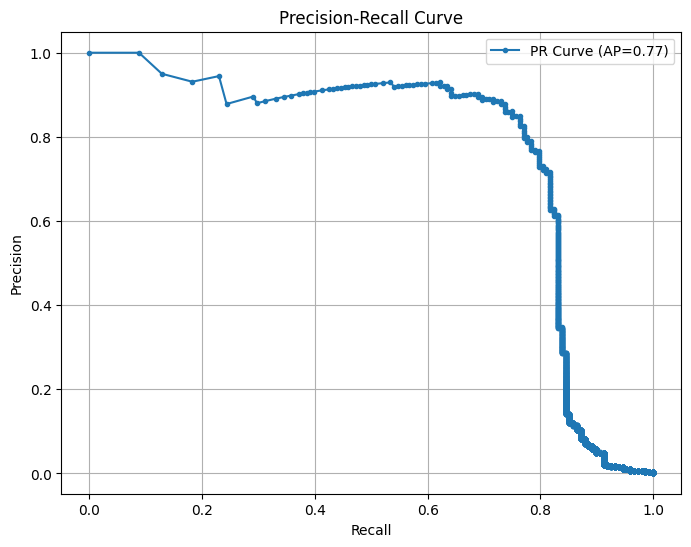

<Figure size 800x600 with 0 Axes>

<Figure size 800x600 with 0 Axes>

In [26]:
# Assume you have:
# y_test = true labels
# y_pred_proba = predicted probabilities for Class = 1 (fraud)

# Compute precision, recall, thresholds
precision, recall, thresholds = precision_recall_curve(y_test, y_pred_proba)

# Compute average precision# Compute average precision (PR-AUC)
avg_precision = average_precision_score(y_test, y_pred_proba)

# Plot Precision-Recall curve
plt.figure(figsize=(8, 6))
plt.plot(recall, precision, marker='.', label=f'PR Curve (AP={avg_precision:.2f})')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.legend()
plt.grid()
plt.show()

# Optional: Plot Precision and Recall vs Threshold
plt.figure(figsize=(8, 6))
